In [ ]:
import spacy
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [10]:
def load_model():
  try:
    return spacy.load("es_core_news_sm")
  except Exception:
    try:
      from spacy.cli import download
      download("es_core_news_sm")
      return spacy.load("es_core_news_sm")
    except Exception as e:
      raise RuntimeError("No se pudo cargar el modelo de spaCy 'es_core_news_sm'.") from e

nlp = load_model()

In [11]:
def load_dataset(path):
  df = pd.read_csv(path, encoding="utf-8")
  df = df.dropna(subset=["review_text", "gender"]).copy()
  df["review_text"] = df["review_text"].astype(str)
  df["gender"] = df["gender"].astype(str)
  return df

df = load_dataset("data/film_reviews_result_clean.csv")

In [18]:
def extract_syntactic_features(doc):
  "Extrae características sintácticas de una review"
  features = {
    'num_sentences': len(list(doc.sents)),
    'num_tokens': len(doc),
    'avg_sentence_length': 0,
    'tree_depth': 0,
    'num_clauses': 0,
    'pos_distribution': Counter(),
    'dep_distribution': Counter(),
    'dependency_pairs': [],
    'syntactic_complexity': 0
  }
  
  sentence_len = []
  all_depths = []
  for sent in doc.sents:
    sentence_len.append(len(sent))
    
    # Calcular profundidad del árbol para cada oración
    for token in sent:
      depth = get_token_depth(token)
      all_depths.append(depth)
    
    # Contar cláusulas (verbos principales)
    features['num_clauses'] += sum(1 for token in sent if token.pos_ == 'VERB' and token.dep_ in ['ROOT', 'ccomp', 'xcomp', 'advcl'])
  
  # Distribución de POS tags
  for token in doc:
    features['pos_distribution'][token.pos_] += 1
    features['dep_distribution'][token.dep_] += 1
    
    # Pares de dependencias (padre -> hijo)
    if token.head != token:
      features['dependency_pairs'].append((token.head.pos_, token.dep_, token.pos_))
    
  features['avg_sentence_length'] = np.mean(sentence_len) if sentence_len else 0
  features['tree_depth'] = max(all_depths) if all_depths else 0
  features['syntactic_complexity'] = features['tree_depth'] * features['num_clauses']
    
  return features

def get_token_depth(token):
  "Calcula la profundidad de un token en el árbol de dependencias"
  depth = 0
  current = token
  while current.head != current:
    depth += 1
    current = current.head
  return depth

In [19]:
def analyze_dataset_grammar(df, nlp, sample_size=1000):
  "Analiza las características gramaticales de un dataset de reviews"
  if sample_size:
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
  else:
    df_sample = df
  
  print(f"Analizando {len(df_sample)} reviews...")
  
  results = []
  
  for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Procesando reviews"):
    try:
      # Procesar texto con spaCy (limitamos longitud para eficiencia)
      text = row['review_text'][:10000]  # Limitar a 10k caracteres
      doc = nlp(text)
      
      # Extraer características
      features = extract_syntactic_features(doc)
      
      # Agregar metadatos
      result = {
        'review_id': idx,
        'gender': row['gender'],
        'review_rate': row['review_rate'],
        **features
      }
      
      results.append(result)
      
    except Exception as e:
      print(f"Error procesando review {idx}: {e}")
      continue
    
  return results

In [22]:
SAMPLE_SIZE = 1000 # Cambiar a None para analizar todo el dataset
result = analyze_dataset_grammar(df, nlp, sample_size=SAMPLE_SIZE)

Analizando 1000 reviews...


Procesando reviews: 100%|██████████| 1000/1000 [00:26<00:00, 37.47it/s]


In [27]:
def create_statistical_summary(results):
  "Genera las estadísticas de las características gramaticales"
  # Convertir a DataFrame
  df_features = pd.DataFrame([
    {
      'review_id': r['review_id'],
      'gender': r['gender'],
      'review_rate': r['review_rate'],
      'num_sentences': r['num_sentences'],
      'num_tokens': r['num_tokens'],
      'avg_sentence_length': r['avg_sentence_length'],
      'tree_depth': r['tree_depth'],
      'num_clauses': r['num_clauses'],
      'syntactic_complexity': r['syntactic_complexity']
    }
    for r in results
  ])

  print("\n=== ESTADÍSTICAS GENERALES ===")
  print(df_features[
    [
      'num_sentences', 
      'num_tokens', 
      'avg_sentence_length',
      'tree_depth', 
      'num_clauses', 
      'syntactic_complexity'
    ]
  ].describe())

  print("\n=== ESTADÍSTICAS POR CALIFICACIÓN ===")
  print(df_features.groupby('review_rate')[
    [
      'avg_sentence_length',
      'tree_depth',
      'syntactic_complexity'
    ]
  ].mean())

  return df_features

def analyze_pos_patterns(results):
  "Analiza patrones de POS tags"

  # Agregar todas las distribuciones
  total_pos = Counter()
  for r in results:
    total_pos.update(r['pos_distribution'])

  return total_pos

def analyze_dependency_patterns(results, K1=10, K2=10):
  "Analiza patrones de dependencias"

  # Agregar todas las dependencias
  total_deps = Counter()
  dependency_pairs = []

  for r in results:
    total_deps.update(r['dep_distribution'])
    dependency_pairs.extend(r['dependency_pairs'])

  print(f"\n=== {K1} RELACIONES DE DEPENDENCIA ===")
  for dep, count in total_deps.most_common(15):
    print(f"{dep}: {count}")

  print(f"\n=== {K2} PATRONES DE DEPENDENCIA (Head POS -> Dep -> Child POS) ===")
  pair_counter = Counter(dependency_pairs)
  for pair, count in pair_counter.most_common(10):
    head_pos, dep, child_pos = pair
    print(f"{head_pos} --[{dep}]--> {child_pos}: {count}")

  return total_deps, pair_counter

In [34]:
df_features = create_statistical_summary(result)


=== ESTADÍSTICAS GENERALES ===
       num_sentences  num_tokens  avg_sentence_length   tree_depth  \
count    1000.000000  1000.00000          1000.000000  1000.000000   
mean       10.660000   286.27100            28.255698     8.508000   
std         8.085529   229.95108            12.871320     2.602827   
min         1.000000    27.00000             6.818182     3.000000   
25%         5.000000   128.00000            20.000000     7.000000   
50%         8.000000   211.00000            25.781250     8.000000   
75%        13.000000   361.25000            33.294643    10.000000   
max        55.000000  1253.00000           140.000000    22.000000   

       num_clauses  syntactic_complexity  
count   1000.00000           1000.000000  
mean      15.33700            144.337000  
std       12.77359            151.574227  
min        0.00000              0.000000  
25%        7.00000             48.000000  
50%       12.00000             91.000000  
75%       20.00000            180.00

In [37]:
total_pos = analyze_pos_patterns(result)

In [33]:
total_deps, _ = analyze_dependency_patterns(result)


=== 10 RELACIONES DE DEPENDENCIA ===
det: 36460
punct: 34058
case: 30292
obj: 17222
advmod: 16875
amod: 15275
nsubj: 14650
nmod: 14371
mark: 12186
conj: 11553
obl: 11226
cc: 10949
ROOT: 10659
advcl: 7077
acl: 6494

=== 10 PATRONES DE DEPENDENCIA (Head POS -> Dep -> Child POS) ===
NOUN --[det]--> DET: 30111
NOUN --[case]--> ADP: 21919
NOUN --[amod]--> ADJ: 12896
VERB --[punct]--> PUNCT: 12183
VERB --[obj]--> NOUN: 9604
NOUN --[punct]--> PUNCT: 9342
NOUN --[nmod]--> NOUN: 9106
VERB --[obl]--> NOUN: 6513
VERB --[advmod]--> ADV: 6405
NOUN --[acl]--> VERB: 4749


In [ ]:
def plot_visualizations(df_features, total_pos, total_deps, savefig=False):
  "Crea visualizaciones de los análisis"

  fig, axes = plt.subplots(2, 3, figsize=(18, 12))

  # 1. Distribución de profundidad del árbol
  axes[0, 0].hist(df_features['tree_depth'], bins=30, color='skyblue', edgecolor='black')
  axes[0, 0].set_title('Distribución de Profundidad del Árbol Sintáctico')
  axes[0, 0].set_xlabel('Profundidad')
  axes[0, 0].set_ylabel('Frecuencia')

  # 2. Complejidad sintáctica por calificación
  df_features.boxplot(column='syntactic_complexity', by='review_rate', ax=axes[0, 1])
  axes[0, 1].set_title('Complejidad Sintáctica por Calificación')
  axes[0, 1].set_xlabel('Calificación')
  axes[0, 1].set_ylabel('Complejidad Sintáctica')

  # 3. Longitud promedio de oraciones por calificación
  df_features.groupby('review_rate')['avg_sentence_length'].mean().plot(kind='bar', ax=axes[0, 2], color='coral')
  axes[0, 2].set_title('Long. Promedio de Oración por Calificación')
  axes[0, 2].set_xlabel('Calificación')
  axes[0, 2].set_ylabel('Tokens promedio')
  axes[0, 2].tick_params(axis='x', rotation=0)

  # 4. Top POS tags
  top_pos = dict(total_pos.most_common(10))
  axes[1, 0].barh(list(top_pos.keys()), list(top_pos.values()), color='lightgreen')
  axes[1, 0].set_title('Top 10 POS Tags')
  axes[1, 0].set_xlabel('Frecuencia')

  # 5. Top dependencias
  top_deps = dict(total_deps.most_common(10))
  axes[1, 1].barh(list(top_deps.keys()), list(top_deps.values()), color='salmon')
  axes[1, 1].set_title('Top 10 Relaciones de Dependencia')
  axes[1, 1].set_xlabel('Frecuencia')

  # 6. Correlación entre métricas
  corr_data = df_features[['tree_depth', 'num_clauses', 'syntactic_complexity', 'review_rate']].corr()
  sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
  axes[1, 2].set_title('Correlación entre Métricas')

  plt.tight_layout()
  if savefig: 
    plt.savefig('grammar_analysis.png', dpi=300, bbox_inches='tight')
  plt.show()


Visualización guardada como 'grammar_analysis.png'


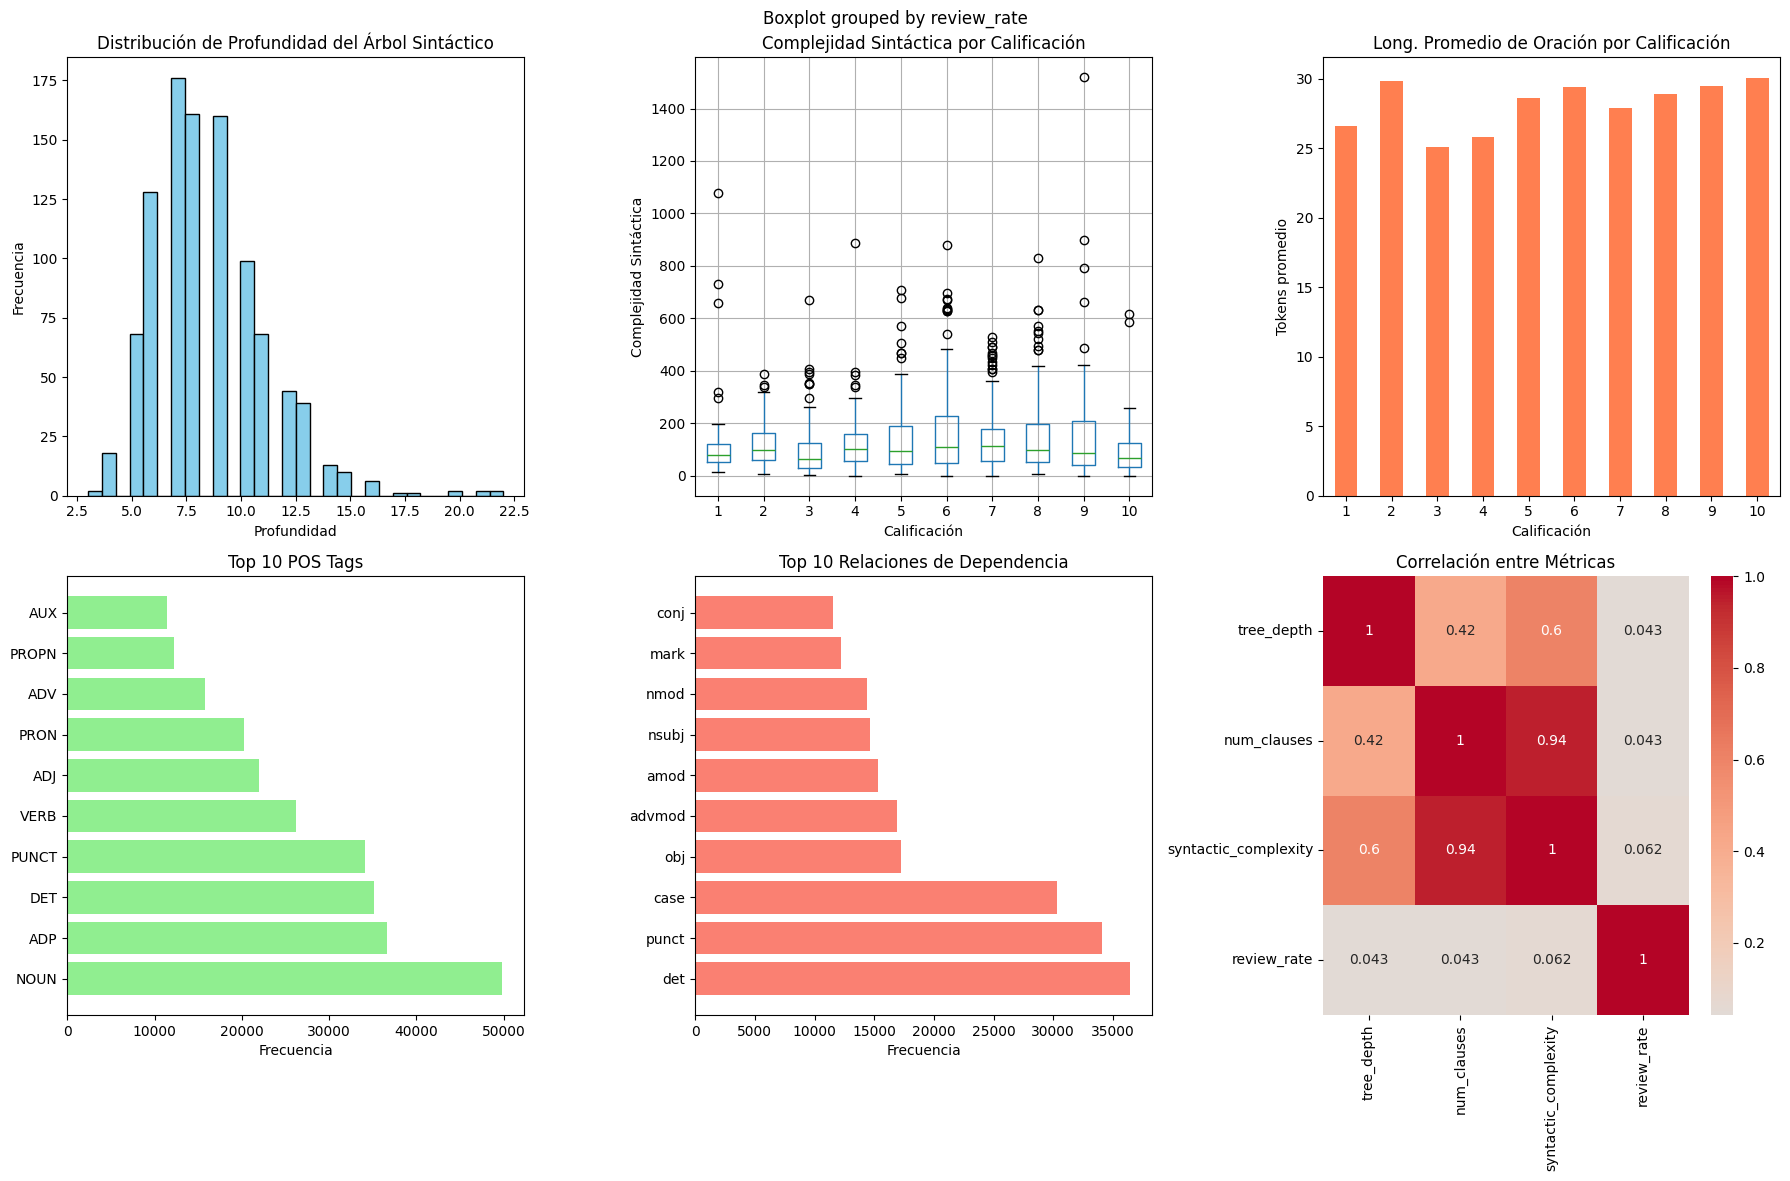

In [38]:
plot_visualizations(df_features, total_pos, total_deps)